<a href="https://colab.research.google.com/github/verakimoo/2026-1-Project/blob/main/G_S_%EB%B2%95%EC%B9%99_%EA%B8%B0%EB%B0%98_PINN_%EB%AA%A8%EB%8D%B8_%EA%B5%AC%EC%B6%95.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

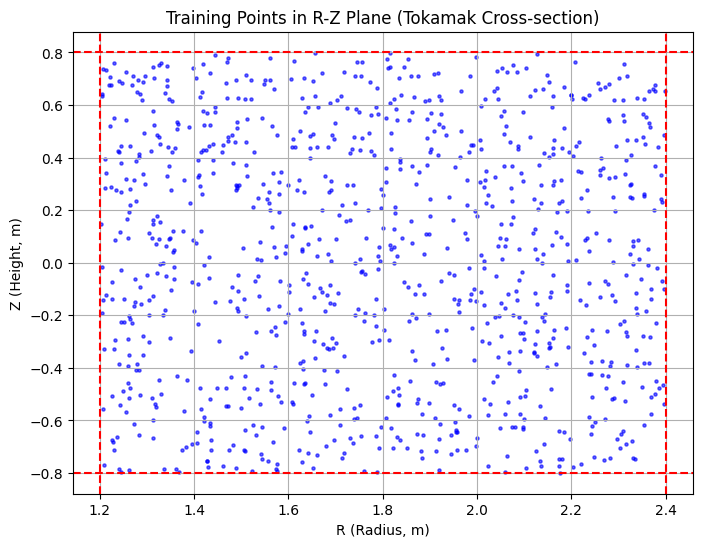

In [1]:
import torch
import matplotlib.pyplot as plt

# 1. 좌표계 범위 설정
R_min, R_max = 1.2, 2.4
Z_min, Z_max = -0.8, 0.8

# 2. 1000개의 무작위 학습용 점(Point) 생성
num_points = 1000
R_coords = torch.empty(num_points, 1).uniform_(R_min, R_max)
Z_coords = torch.empty(num_points, 1).uniform_(Z_min, Z_max)

# 3. 시각화
plt.figure(figsize=(8, 6))
plt.scatter(R_coords.numpy(), Z_coords.numpy(), s=5, alpha=0.6, color='blue')
plt.title("Training Points in R-Z Plane (Tokamak Cross-section)")
plt.xlabel("R (Radius, m)")
plt.ylabel("Z (Height, m)")
plt.grid(True)
plt.axvline(R_min, color='red', linestyle='--')
plt.axvline(R_max, color='red', linestyle='--')
plt.axhline(Z_min, color='red', linestyle='--')
plt.axhline(Z_max, color='red', linestyle='--')
plt.show()

In [2]:
# 미분 값 훈련하는 핵심 로직
def compute_ge_loss(model, r, z):
    r.requires_grad = True
    z.requires_grad = True

    psi = model(r, z) # 신경망 출력

    # 1계 미분: d_psi/dr, d_psi/dz
    d_psi = torch.autograd.grad(psi, [r, z], grad_outputs=torch.ones_like(psi), create_graph=True)
    psi_r, psi_z = d_psi[0], d_psi[1]

    # 2계 미분: d2_psi/dr2, d2_psi/dz2 (G-S 식의 델 스타 연산자에 필요)
    psi_rr = torch.autograd.grad(psi_r, r, grad_outputs=torch.ones_like(psi_r), create_graph=True)[0]
    psi_zz = torch.autograd.grad(psi_z, z, grad_outputs=torch.ones_like(psi_z), create_graph=True)[0]

    # 여기에 G-S 식의 나머지 항(압력, 전류 등)을 더해 Loss를 만듭니다.
    return psi_rr, psi_zz # 이것이 0에 가까워지도록 훈련시키는 것임

모델 구조:
PINN(
  (net): Sequential(
    (0): Linear(in_features=2, out_features=40, bias=True)
    (1): Tanh()
    (2): Linear(in_features=40, out_features=40, bias=True)
    (3): Tanh()
    (4): Linear(in_features=40, out_features=40, bias=True)
    (5): Tanh()
    (6): Linear(in_features=40, out_features=40, bias=True)
    (7): Tanh()
    (8): Linear(in_features=40, out_features=1, bias=True)
  )
)
사용 중인 디바이스: cpu


In [5]:
# 1. 가상의 입력 데이터 (R=1.8, Z=0.0 중심의 점 5개)
r_test = torch.tensor([[1.7], [1.75], [1.8], [1.85], [1.9]], requires_grad=True)
z_test = torch.tensor([[0.0], [0.0], [0.0], [0.0], [0.0]], requires_grad=True)

# 2. 함수 실행
p_rr, p_zz = compute_ge_loss(model, r_test, z_test)

# 3. 결과 출력
print("R 방향 2계 미분값 (psi_rr):")
print(p_rr.detach().numpy()) # 신경망이 계산한 곡률 데이터

print("\nZ 방향 2계 미분값 (psi_zz):")
print(p_zz.detach().numpy())

R 방향 2계 미분값 (psi_rr):
[[0.00600521]
 [0.00596872]
 [0.00588463]
 [0.00575802]
 [0.00559403]]

Z 방향 2계 미분값 (psi_zz):
[[0.03240371]
 [0.03230421]
 [0.03216607]
 [0.03199302]
 [0.03178887]]


In [6]:
def compute_gs_residual(model, r, z):
    # 미분 계산을 위해 입력값의 기울기 추적 활성화
    r.requires_grad = True
    z.requires_grad = True

    # 1. 신경망 출력 (psi)
    psi = model(r, z)

    # 2. 1계 미분 (d_psi/dr, d_psi/dz)
    d_psi = torch.autograd.grad(psi, [r, z], grad_outputs=torch.ones_like(psi), create_graph=True)
    psi_r, psi_z = d_psi[0], d_psi[1]

    # 3. 2계 미분 (d2_psi/dr2, d2_psi/dz2)
    psi_rr = torch.autograd.grad(psi_r, r, grad_outputs=torch.ones_like(psi_r), create_graph=True)[0]
    psi_zz = torch.autograd.grad(psi_z, z, grad_outputs=torch.ones_like(psi_z), create_graph=True)[0]

    # 4. Grad-Shafranov 좌변 (Delta* psi) 구현
    # 공식: psi_rr - (1/r)*psi_r + psi_zz
    delta_star_psi = psi_rr - (1.0 / r) * psi_r + psi_zz

    return delta_star_psi, psi

    # 물리적 상수 설정 (임의의 상수값으로 시작)
mu_0 = 4e-7 * 3.141592
dp_dpsi = -0.1  # 압력 구배 (상수 가정)
F_dF_dpsi = -0.1 # 전류 항 (상수 가정)

# 물리 법칙 오차 계산
def get_physics_loss(delta_star_psi, r):
    # G-S 우변: -mu_0 * R^2 * p'(psi) - F*F'(psi)
    rhs = -mu_0 * (r**2) * dp_dpsi - F_dF_dpsi

    # 좌변과 우변의 차이가 0에 가까워져야 함
    loss_pde = torch.mean((delta_star_psi - rhs)**2)
    return loss_pde

In [7]:
import torch.optim as optim

# 1. 옵티마이저 설정 (통계학의 최적화 알고리즘)
# Adam은 학습률을 스스로 조절하며 빠르게 수렴하는 인기 있는 알고리즘입니다.
optimizer = optim.Adam(model.parameters(), lr=0.001)

# 2. 학습 루프 (Training Loop)
epochs = 1000  # 1,000번 반복 학습

for epoch in range(epochs):
    optimizer.zero_grad() # 이전 단계의 기울기 초기화

    # 2-1. 물리 법칙 기반 오차 계산 (Step 3에서 만든 함수 활용)
    # 실제 수치 범위 내에서 무작위 점 생성 (매번 새로 생성하여 일반화 성능 높임)
    r_train = torch.empty(500, 1).uniform_(1.2, 2.4).to(device)
    z_train = torch.empty(500, 1).uniform_(-0.8, 0.8).to(device)

    delta_star_psi, psi_out = compute_gs_residual(model, r_train, z_train)
    loss_pde = get_physics_loss(delta_star_psi, r_train)

    # 2-2. 경계 조건 오차 (Boundary Loss) 추가
    # 벽면(R=1.2, 2.4 또는 Z=±0.8)에서는 psi가 0이어야 한다는 물리적 제약
    r_wall = torch.tensor([[1.2], [2.4]]).to(device)
    z_wall = torch.tensor([[0.0], [0.0]]).to(device)
    psi_wall = model(r_wall, z_wall)
    loss_bc = torch.mean(psi_wall**2) # 0에 가까워지도록 설정

    # 2-3. 전체 손실 함수 합산
    total_loss = loss_pde + 10.0 * loss_bc # 경계 조건의 가중치를 높게 설정

    # 2-4. 역전파 및 가중치 업데이트
    total_loss.backward()
    optimizer.step()

    # 100번마다 진행 상황 출력
    if epoch % 100 == 0:
        print(f"Epoch {epoch}: Total Loss = {total_loss.item():.6f}, PDE Loss = {loss_pde.item():.6f}")

print("학습 완료!")

Epoch 0: Total Loss = 0.007768, PDE Loss = 0.005312
Epoch 100: Total Loss = 0.000436, PDE Loss = 0.000432
Epoch 200: Total Loss = 0.000250, PDE Loss = 0.000250
Epoch 300: Total Loss = 0.000115, PDE Loss = 0.000115
Epoch 400: Total Loss = 0.000048, PDE Loss = 0.000045
Epoch 500: Total Loss = 0.000240, PDE Loss = 0.000016
Epoch 600: Total Loss = 0.000008, PDE Loss = 0.000008
Epoch 700: Total Loss = 0.000008, PDE Loss = 0.000005
Epoch 800: Total Loss = 0.000005, PDE Loss = 0.000003
Epoch 900: Total Loss = 0.000005, PDE Loss = 0.000004
학습 완료!


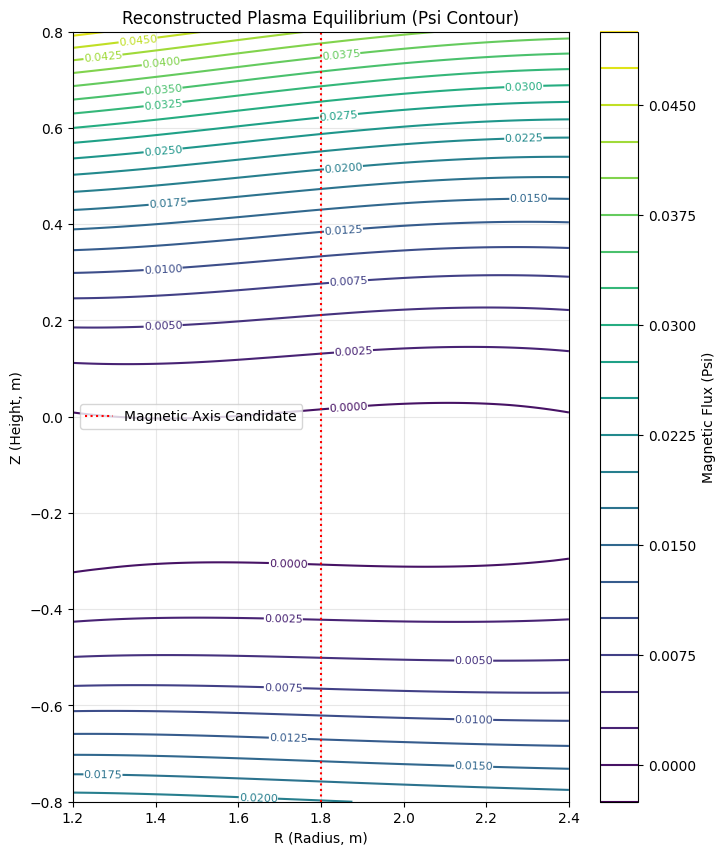

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# 1. 시각화를 위한 격자(Grid) 생성
R_grid = np.linspace(1.2, 2.4, 100)
Z_grid = np.linspace(-0.8, 0.8, 100)
RR, ZZ = np.meshgrid(R_grid, Z_grid)

# 2. 신경망 모델에 넣기 위해 데이터 변환
r_tensor = torch.tensor(RR.flatten()[:, None], dtype=torch.float32).to(device)
z_tensor = torch.tensor(ZZ.flatten()[:, None], dtype=torch.float32).to(device)

# 3. 모델로부터 psi 값 예측 (추론 모드)
model.eval()
with torch.no_grad():
    psi_pred = model(r_tensor, z_tensor).cpu().numpy()
    psi_grid = psi_pred.reshape(RR.shape)

# 4. 등고선 그리기 (Magnetic Flux Surfaces)
plt.figure(figsize=(8, 10))
contour = plt.contour(RR, ZZ, psi_grid, levels=20, cmap='viridis')
plt.clabel(contour, inline=True, fontsize=8)
plt.title("Reconstructed Plasma Equilibrium (Psi Contour)")
plt.xlabel("R (Radius, m)")
plt.ylabel("Z (Height, m)")
plt.axvline(1.8, color='red', linestyle=':', label='Magnetic Axis Candidate')
plt.colorbar(label='Magnetic Flux (Psi)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()